# Import

In [1]:
from Utilities.utils import *
from Utilities.utils_feature_extraction import * 

current_working_dir = os.path.join(Path(os.getcwd()).parent,'data/preproc//') 
pp_file = current_working_dir + r'\Awake\178_1_7_run_2701023_1720'
# dat_path = current_working_dir + r'\preproc\Awake\behaviour\\'


# Main

____________________________________________________________________________________________________
 Processing: example data
Processing sequence type: 1


C:\Users\Emmett Thompson\AppData\Local\Temp\ipykernel_30008\2923376908.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  unmasked_spikes_df = pickle.load(handle)


Processing sequence type: 2
Processing sequence type: 3
Processing sequence type: 4
Processing sequence type: 5
Processing sequence type: 6
back_2022-03-30T15_02_32DLC_resnet50_port-tracking_back_viewMay2shuffle1_500000.h5
back_2022-03-30T15_02_32DLC_resnet50_task-tracking_backviewApr6shuffle1_800000.h5
['head_centre' 'implant_centre' 'left_ear' 'right_ear' 'tail_base']
back_2022-03-30T15_02_32DLC_resnet50_port-tracking_back_viewMay2shuffle1_500000.h5
back_2022-03-30T15_02_32DLC_resnet50_task-tracking_backviewApr6shuffle1_800000.h5
Overlap detected near curve ends
Overlap detected near curve ends
Overlap detected near curve ends


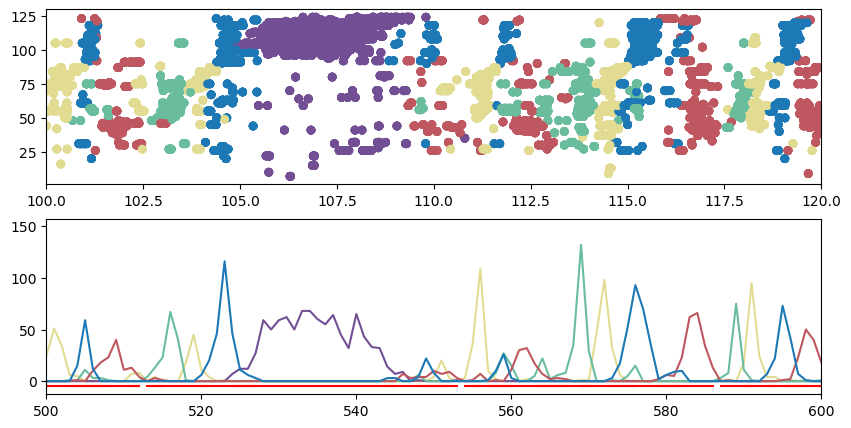

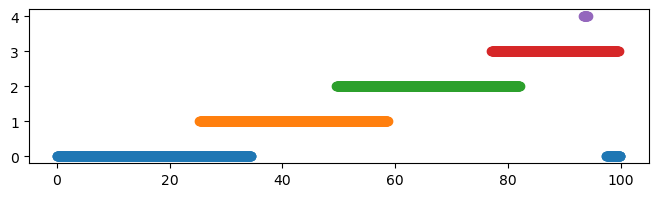

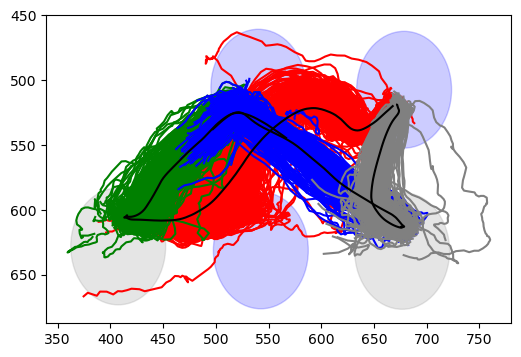

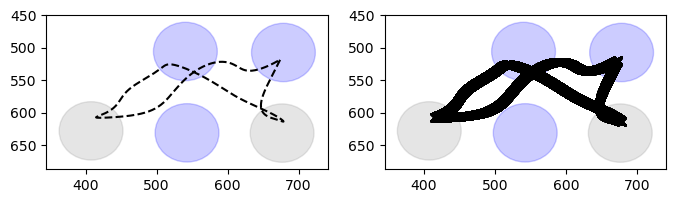

In [2]:

print('____________________________________________________________________________________________________')
print(f"\033[1m Processing: {'example data'}\033[0m")

############
# LOAD example data 
behav_sync_df = pd.read_csv(current_working_dir + '/Awake/behaviour/Behav_Ephys_Camera_Sync.csv')
transition_sync_df = pd.read_csv(current_working_dir + '/Awake/behaviour/Transition_data_sync.csv')

with open(pp_file + r'/processed/spikes_seq_type_adjusted.pickle', 'rb') as handle:
    unmasked_spikes_df = pickle.load(handle)
    

with open(pp_file + r'/processed/neuron_order', 'rb') as handle:
    awake_neuron_order = pickle.load(handle)
    
    
colors = ['---',
        '#E2DC92',
        '#C6963E',
        '#724F94',
        '#69BD9D',
        '#BE575F',
        '#1C79B5',
        '#264999']

#load json
import json
params = None
for file in os.listdir(pp_file + r'/trainingData'):
    if 'json' in file:
        param_path = os.path.join(pp_file + r'/trainingData', file)
        with open(param_path,'r') as f:
            params = json.load(f)
awake_time_span = params['time_span'][0]

# cluster the awake spikes into individual sequence events
seq_event_dfs = process_awake_data_return_seq_dfs(unmasked_spikes_df,awake_time_span,awake_neuron_order,colors,[100,120]) 
## spit the sequence events into individual sequence types
seq_events_dict = split_sequence_events(seq_event_dfs)

# load sequence order
seq_order = [4, 3, 0, 5, 2]

    
############################# movement variability for each motif region ####################
## TRACKING PREP - laod in data, find average curves etc. 
#############################################################################################

track_path = current_working_dir + r'Awake/tracking//'

back_head_centre_df = load_H5_bodypart(track_path,'back','head_centre')
p1,p2,p3,p4,p5 = load_H5_ports(track_path,'back')

camera_timestamps_df = pd.read_csv(track_path + 'camera_timestamps_df.csv')

# get continuous regions information
continuous_regions_df = get_sequence_regions(pp_file,seq_order)

if 'epoch' in list(camera_timestamps_df):
    task_mask = camera_timestamps_df.epoch == 'task'
    # find task relevant tracking periods, extract times mouse is close to each behavioural port
    threshold_breaks,port_centroids,current_x,current_y,radius_used = find_task_relevant_tracking_points(back_head_centre_df[task_mask],p1[task_mask],p2[task_mask],p3[task_mask],p4[task_mask],p5[task_mask],radius = 45)
else:
    # find task relevant tracking periods, extract times mouse is close to each behavioural port
    threshold_breaks,port_centroids,current_x,current_y,radius_used = find_task_relevant_tracking_points(back_head_centre_df,p1,p2,p3,p4,p5,radius = 45) 
    
## each of these is a frame so we know the timing between them. ie. one frame is 1/60s 

fps = 1/np.nanmean(np.diff(camera_timestamps_df['Time Stamps'].values))

time_filter = 2 #in s
frame_filter = int(time_filter / (1/fps))

#we know when the mouse is close to each port, so find times when the mouse goes from port to port 
start_port,end_port = 5,2
T1_start_ind, T1_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,4,-1,-1)
start_port,end_port = 2,3
T2_start_ind, T2_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,1,4,5)
start_port,end_port = 3,4
T3_start_ind, T3_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,1,2,5)
start_port,end_port = 4,5
T4_start_ind, T4_end_ind = extract_port_to_port_trajetories(start_port,end_port,frame_filter,threshold_breaks,1,2,3)


# find average curves by taking traject lines and make them roughly equivalent by interpolating so they have the same number of trakcing points, then for each point in each trajectory find the average xy position to create an average trajectory line 
a_curve1,a_curve2,a_curve3,a_curve4 = find_average_curves(port_centroids,T1_start_ind,T1_end_ind,T2_start_ind,T2_end_ind,T3_start_ind,T3_end_ind,T4_start_ind,T4_end_ind,current_x,current_y,buffer = 10, radius = 45)

new = join_curves(a_curve1, a_curve2,cut = True)
new = join_curves(new, a_curve3,cut = True)
new = join_curves(new, a_curve4,cut = True)
# join the two ends together to make a complete circle
complete_average = join_make_full_circle(new,100)

# smooth it if the extracted curve is a bit noisy
complete_average = fourier_smooth_closed(complete_average)

#interpolate to make standardspace:
standard_av_curve = resample_curve(complete_average, num_points = 10000)

# shift the start point of the curve so that is the first time the mous eleaves port 5 radius
standard_av_curve = shift_curve_start(standard_av_curve,port_centroids[-1])

# plot this stuff to check it looks okay
plot_av_and_new_standard_line(complete_average,standard_av_curve,radius_used,port_centroids)





DTW in parallel: 100%|██████████| 12065/12065 [01:38<00:00, 121.96it/s]


254


DTW in parallel: 100%|██████████| 14187/14187 [02:49<00:00, 83.56it/s] 


267


DTW in parallel: 100%|██████████| 7137/7137 [01:38<00:00, 72.50it/s] 


331


DTW in parallel: 100%|██████████| 15704/15704 [01:01<00:00, 255.82it/s]


392


DTW in parallel: 100%|██████████| 33782/33782 [02:19<00:00, 242.95it/s]


468


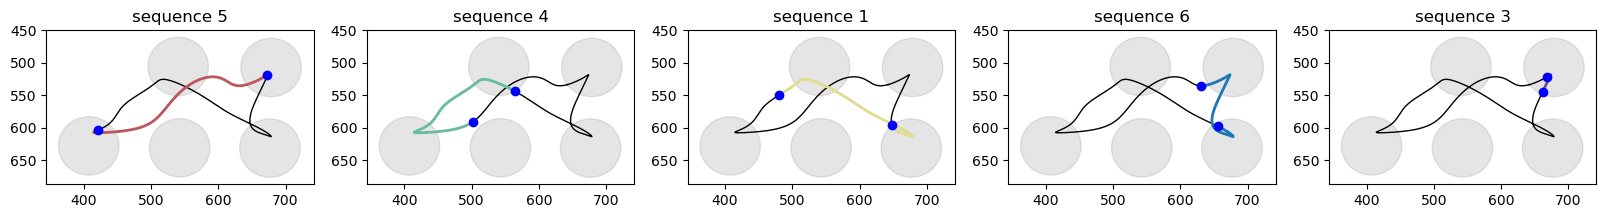

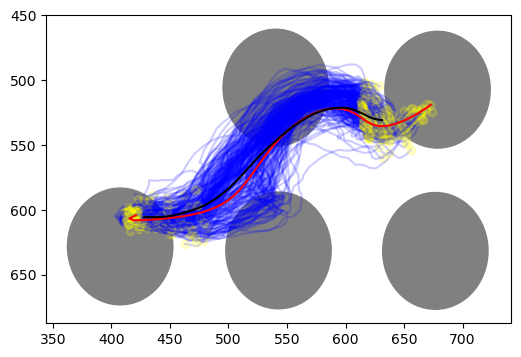

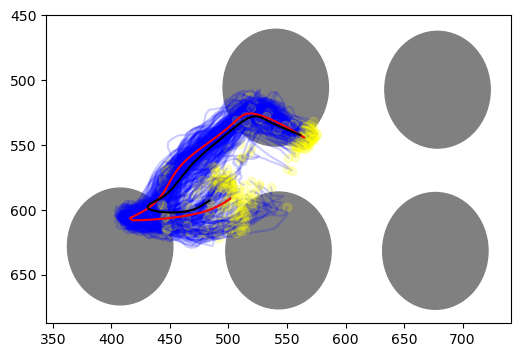

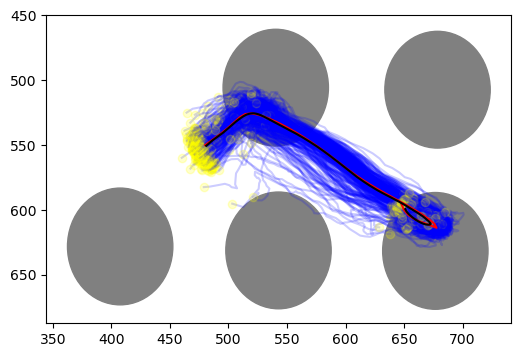

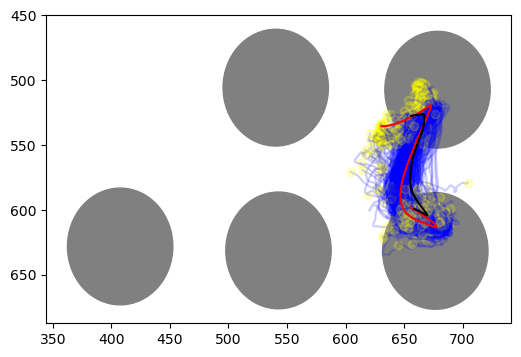

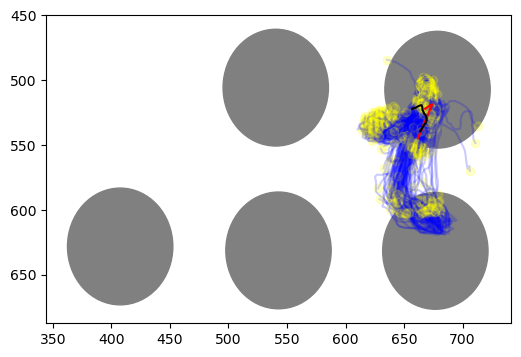

In [3]:
##### FIND THE MOTIF REGIONS - #################################
# find all the examples of each motif 
################################################################

# next define the regions of each motif 
motif_start_ends_df = find_motif_points(continuous_regions_df,standard_av_curve,port_centroids,colors,radius_used,num_intermediate_points=50)

#convert to xy coords
full_tracking_coords = []
for ind_,item in enumerate(current_x):
    full_tracking_coords += [[item,current_y[ind_]]]

# now take these start and end points of each motif to find all motif examples:
motif_start_ends = []
for i in range(len(motif_start_ends_df)):

    points = []
    for column in list(motif_start_ends_df):
        row = motif_start_ends_df[(f'{column}')][i]
        points += [row]
        
    centroid_distance_threshold = 8000000  # You need to set an appropriate threshold based on your data.
    radius_threshold = 30
                
    similar_segments = find_similar_segments(full_tracking_coords, points, centroid_distance_threshold,radius_threshold)
    ## each of these is a frame so we know the timing between them. ie. one frame is 1/60s 
    time_filter = 6 #in s
    # minimum distance from start/end centroid
    dist_filter = 60
    # number of closest points to start/end centroid to find and chose from
    num_points = 3
    # number of points to add to the start and end of the trajectory
    add_start_end = 5
    valid_trajectories = process_and_validate_trajectories(full_tracking_coords, similar_segments, points,add_start_end,int(time_filter / (1/fps)),dist_filter,num_points)

    # then remove any duplicates:
    valid_trajectories_filtered = remove_overlaps(valid_trajectories)

    fig, ax = plt.subplots(1, 1,figsize=(6, 4))
    for index,port_centroid in enumerate(port_centroids):
        circle1 = plt.Circle(port_centroid, 45, color='grey', alpha = 1)
        ax.add_patch(circle1)

    trajects = []
    for ind in valid_trajectories_filtered:
        traject = full_tracking_coords[ind[0]:ind[1]]
        trajects += [traject]
        x = [point[0] for point in traject]
        y = [point[1] for point in traject]
        ax.plot(x,y,'-', color = 'blue', alpha = 0.2)
        ax.plot(x[0],y[0],'o', color = 'yellow', alpha = 0.2)
        ax.plot(x[-1],y[-1],'o', color = 'yellow', alpha = 0.2)

    x = [point[0] for point in points]
    y = [point[1] for point in points]
    ax.plot(x,y,'-', color = 'red', alpha = 1)

    av_of_found = interpolate_to_longest_and_find_average_curve(trajects,500)
    x = [point[0] for point in av_of_found]
    y = [point[1] for point in av_of_found]
    ax.plot(x,y,'-', color = 'k', alpha = 1)
        
    ax.invert_yaxis()

    print(len(valid_trajectories_filtered))
    
    motif_start_ends += [valid_trajectories_filtered]


100%|██████████| 5/5 [00:51<00:00, 10.31s/it]


done
____________________________________________________________________________________________________
____________________________________________________________________________________________________


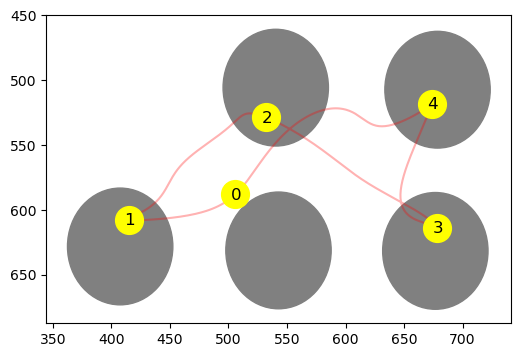

In [5]:

##### 1 FIND THE MOVEMENT VARIABILITY FOR EACH MOTIF - 
# using two different methods, h distance and dtw
#############################################################################################

# needs to be large to make the h distance calcualtions accurate
motif_start_ends_df_large = find_motif_points(continuous_regions_df,standard_av_curve,port_centroids,colors,radius_used,num_intermediate_points=10000)
plt.close()
# slightly smaller to save computational power when doing dtw
motif_start_ends_df_medium = find_motif_points(continuous_regions_df,standard_av_curve,port_centroids,colors,radius_used,num_intermediate_points=300)
plt.close()

motif_dists = []
motif_std_dists = []
motif_median_dtws = []
motif_std_dtws = []
for i in tqdm(range(len(motif_start_ends_df_large))):

    points = []
    for column in list(motif_start_ends_df_large):
        row = motif_start_ends_df_large[(f'{column}')][i]
        points += [row]
        
    points2 = []
    for column in list(motif_start_ends_df_medium):
        row = motif_start_ends_df_medium[(f'{column}')][i]
        points2 += [row]

    motif_ranges = motif_start_ends[i]
    median_distances = []
    std_distances = []
    dtws = []
    for start, end in motif_ranges:
        segment = full_tracking_coords[start:end]
        
        """ 
        a simplified version of the Hausdorff distance
        "" Measures the greatest distance between any point on one trajectory to the closest point on the other.
        determine deviation from average
        - for each tracking point in each trajectory find the point on the relevant interpolated average line which it is closest to
        - this gives us a list of distances (deviations) from the average for each trajectory line
        - this can be used to find the standard devation of the average distance from the average line.
        - this gives us a meausre of how steretyped the port-port trjectories were:
        - stereotyped = similar to average line = smaller devation
        - not stereotyped = different to average line = larger devation ""
        """ 
        distances = closest_points_distances(segment, points)
        median_distances.append(np.median(distances))
        std_distances.append(np.std(distances))
        
        """
        dynamic time warping distance 
        WHAT IS THE DTW NUMBER:
        here i take the mean , so the number represents, trajectories, when optimally aligned to teh average line, the mean amount by which they deviate in total (here in mm). This doesn't necessarily mean each corresponding point deviates that many mm—
        it's the total sum of all point-to-point deviations, which can vary depending on the trajectory.
        eg. "The Dynamic Time Warping (DTW) distance between the two trajectories was xx mm, representing the total accumulated deviation over the entire alignment."
        I calculate the dwt normalised to length of the trajectory
        """
        dtws += [normalized_dtw(segment, points2)]
        
                
    # for h distance 
    motif_dists.append(median_distances)
    motif_std_dists.append(std_distances)
    # for dtw
    motif_median_dtws.append(np.nanmean(dtws))
    motif_std_dtws.append(np.std(dtws))

# put the data into vars
all_motif_mean_dists = [np.nanmean(dist) for dist in motif_dists]
all_motif_std_dists = [np.nanmean(std_dist) for std_dist in motif_std_dists]


## convert to cm, we know distance bwteen two ports should be 3cm apart
port_pairs = [0,1],[0,3],[2,4],[0,2],[3,4]
ptp_distances = []
for pair in port_pairs:
    ptp_distances += [math.sqrt((port_centroids[pair[0]][0] - port_centroids[pair[1]][0])**2 + (port_centroids[pair[0]][-1] - port_centroids[pair[1]][-1])**2)]
_1_mm = (np.nanmean(ptp_distances)/3)/10 

all_motif_mean_dists_mm = np.array(all_motif_mean_dists)/_1_mm
all_motif_std_dists_mm = np.array(all_motif_std_dists)/_1_mm

all_motif_mean_dtws_mm = np.array(motif_median_dtws)/_1_mm
all_motif_std_dtws_mm = np.array(motif_std_dtws)/_1_mm
    

### 2 FIND VARIANCE IN TIME TAKEN TO DO EACH MOTIF - also average movement speed
#############################################################################################

# average speed - distance over time
# speed variability, 

all_motif_mean_speed_mm_s = []
all_motif_mean_std_speed_mm_s = []
for motif_ranges in motif_start_ends:
    segments = []
    for start, end in motif_ranges:
        segments += [full_tracking_coords[start:end]]
    # Calculate average speeds and speed variability
    speed_std,speed_mean = calculate_speed_variability(segments, _1_mm, fps)

    all_motif_mean_speed_mm_s += [speed_mean]
    all_motif_mean_std_speed_mm_s += [speed_std]


###################################################################
#GENERAL BEHAVIOURAL/TASK FEATURES
###################################################################

# ########### 9 training level change in that session   
# t_level_change = max(behav_sync_df['TrainingLevel']) - min(behav_sync_df['TrainingLevel'])

########### 3 relative proportion expressed. (was a sequence done more often by the mouse)
absolute_total_seqs  = []
for seq_id in seq_order:
    absolute_total_seqs += [len(seq_events_dict[str(seq_id+1)])]
# sequence_expression_proportion = np.array(total_seqs)/sum(total_seqs)

########### 11.+ 12. average distance (seconds) to next reward and proportion linked to reward. 
# remove the nans from the reward column 
reward_times = behav_sync_df.dropna(subset=['Reward_Times']).Reward_Times.values

# calcuate the ephys behaviour offset
ephys_behaviour_offset = behav_sync_df['PokeIN_EphysTime'][0] - behav_sync_df['PokeIn_Time'][0]
mean_dist_to_reward = []
proportion_close_to_reward = []
for seq_id in seq_order:
    current_seq = str(seq_id+1)
    seq_events_dict[current_seq]
    
    dist_next_reward = []
    for i in range(len(seq_events_dict[current_seq])):
        # in ephys time
        event_start_ephys = min(seq_events_dict[current_seq][i].timestamp) + awake_time_span[0]
        event_end_ephys = max(seq_events_dict[current_seq][i].timestamp) + awake_time_span[0]
        # in bpod time
        event_start_bpod_time = event_start_ephys - ephys_behaviour_offset
        event_end_bpod_time = event_end_ephys - ephys_behaviour_offset
        
        dist_next_reward += [distance_to_next_reward(event_start_bpod_time, event_end_bpod_time, reward_times)]
    #remove extreme values
    dist_next_reward_extremes_removed = [item for item in dist_next_reward if item is not None and item < 30]
    mean_dist_to_reward += [np.nanmean(dist_next_reward_extremes_removed)]
    proportion_close_to_reward += [len([item for item in dist_next_reward if item is not None and item < 3])/len(dist_next_reward)]
    
############## 13. motif error rate (take the closest two ports and see what the error rate was there?)  
###################################
# find the closest two ports for each sequence type and then calculate the error rate

# define 'port' positions on the average curve, ie. the closest point on the trajectory to each port...when the mouse would have poked its nose 
visited_ports_locations,visited_ports_prcnt = associate_ports_with_curve(standard_av_curve,port_centroids)

## plot this for good measure
fig, ax = plt.subplots(1, 1,figsize=(6, 4))
for index,port_centroid in enumerate(port_centroids):
    circle1 = plt.Circle(port_centroid, 45, color='grey', alpha = 1)
    ax.add_patch(circle1)
x = [point[0] for point in standard_av_curve]
y = [point[1] for point in standard_av_curve]
ax.plot(x,y,'-', color = 'red', alpha = 0.3)
for i, point in enumerate(visited_ports_locations):
    ax.plot(point[0], point[1], 'o',c = 'yellow', markersize=20)
    ax.text(point[0]-4, point[1]+4, str(i), fontsize=12)
ax.invert_yaxis()

# find port-port transitions that best represent the sequence 
seq_regions = [[continuous_regions_df.start[i],continuous_regions_df.end[i]] for i in range(len(continuous_regions_df))]
enclosing_ports = find_best_ports(seq_regions, visited_ports_prcnt)


## find the transition errors 
transitions = []
for i in range(1,len(behav_sync_df.Port.values)):
    transit_time = behav_sync_df.PokeOut_Time.values[i] - behav_sync_df.PokeIn_Time.values[i-1]
    if transit_time < 2:
        transitions += [[behav_sync_df.Port.values[i-1],behav_sync_df.Port.values[i]]]
    else:
        transitions += [['pause']]

error_rate_by_motif = []      
for seq_ports in enclosing_ports:
    transit_goal = port_transitions(seq_ports[0], seq_ports[1])

    transit_goal_in_port_nums = np.array([2,1,6,3,7])[np.array(transit_goal)]
    results = compute_transition_accuracy(transitions, transit_goal_in_port_nums)
    error_rate_by_motif += [np.nanmean([results[item]['pct_error'] for item in results])]
    
        
print('done')
print('____________________________________________________________________________________________________')
print('____________________________________________________________________________________________________')   

        
        